In [ ]:
# ===================================================================
#  SCRIPT: FILTRAGEM DE REGISTROS DE IMUNOGLOBULINA ANTITETÂNICA (IGHT)
#  OBJETIVO: Extrair apenas os registros de aplicação de IGHT de todos 
#            os arquivos mensais de vacinação do SUS (2025)
# 
# ===================================================================

import pandas as pd                    # Biblioteca principal para manipulação de dados tabulares
import glob                            # Módulo para buscar arquivos por padrão (ex: vacinacao_*_2025.csv)

# -------------------------------------------------------------------
# 1. DEFINIÇÃO DAS COLUNAS QUE DEVEM SER MANTIDAS NO DATASET FINAL
# -------------------------------------------------------------------
# Essas são as colunas relevantes para análise posterior (epidemiológica, logística e equidade)
# Manter apenas essas colunas reduz drasticamente o tamanho do arquivo final
columns_to_keep = [
    'co_cnes_estabelecimento', 'co_condicao_maternal', 'co_documento', 'co_dose_vacina',
    'co_estrategia_vacinacao', 'co_etnia_indigena_paciente', 'co_local_aplicacao',
    'co_lote_vacina', 'co_municipio_estabelecimento', 'co_municipio_paciente',
    'co_natureza_estabelecimento', 'co_origem_registro', 'co_paciente', 'co_pais_paciente',
    'co_raca_cor_paciente', 'co_sistema_origem', 'co_tipo_estabelecimento',
    'co_troca_documento', 'co_vacina', 'co_vacina_categoria_atendimento',
    'co_vacina_fabricante', 'co_vacina_grupo_atendimento', 'co_via_administracao',
    'ds_condicao_maternal', 'ds_dose_vacina', 'ds_estrategia_vacinacao',
    'ds_local_aplicacao', 'ds_nacionalidade_paciente', 'ds_natureza_estabelecimento',
    'ds_origem_registro', 'ds_sistema_origem', 'ds_tipo_estabelecimento', 'ds_vacina',
    'ds_vacina_categoria_atendimento', 'ds_vacina_fabricante',
    'ds_vacina_grupo_atendimento', 'ds_via_administracao', 'dt_deletado_rnds',
    'dt_entrada_rnds', 'dt_vacina', 'no_etnia_indigena_paciente',
    'no_fantasia_estalecimento', 'no_municipio_estabelecimento',
    'no_municipio_paciente', 'no_pais_paciente', 'no_raca_cor_paciente',
    'no_razao_social_estabelecimento', 'no_uf_estabelecimento', 'no_uf_paciente',
    'nu_cep_paciente', 'nu_idade_paciente', 'sg_uf_estabelecimento',
    'sg_uf_paciente', 'sg_vacina', 'st_documento', 'tp_sexo_paciente'
]

# -------------------------------------------------------------------
# 2. BUSCA AUTOMÁTICA DOS ARQUIVOS DE VACINAÇÃO DO ANO DE 2025
# -------------------------------------------------------------------
# Procura todos os arquivos que seguem o padrão "vacinacao_*_2025.csv" no diretório atual
files = glob.glob('vacinacao_*_2025.csv')

# Lista que vai armazenar todos os pedaços filtrados (chunks) de todositos válidos
df_list = []

# Mensagem inicial informando quantos arquivos serão processados
print(f"Iniciando processamento de {len(files)} arquivos...")

# -------------------------------------------------------------------
# 3. LOOP PRINCIPAL: PROCESSAMENTO ARQUIVO POR ARQUIVO
# -------------------------------------------------------------------
for f in files:
    print(f"Lendo arquivo: {f}")                     # Informa qual arquivo está sendo lido agora
    
    try:
        # ---------------------------------------------------------------
        # 3.1 LEITURA DO CSV EM BLOCOS (CHUNKS) PARA EVITAR ESTOURO DE MEMÓRIA
        # ---------------------------------------------------------------
        # Usa chunksize=150000 → lê 150 mil linhas por vez (ideal para arquivos gigantes)
        # sep=';' → padrão do Ministério da Saúde (não é vírgula)
        # encoding='latin1' → compatível com acentos e caracteres especiais brasileiros
        # dtype=str → força tudo como texto (preserva zeros à esquerda em códigos como CNES/IBGE)
        # on_bad_lines='skip' → ignora linhas corrompidas
        reader = pd.read_csv(
            f,
            sep=';', 
            encoding='latin1', 
            encoding_errors='replace',   # Substitui caracteres inválidos por "�"
            dtype=str,                   # Crucial: evita perda de zeros à esquerda em códigos
            chunksize=150000,            # Processa 150.000 linhas por iteração
            on_bad_lines='skip',         # Pula linhas mal formatadas
            low_memory=False             # Desabilita aviso de tipos mistos
        )
        
        chunk_count = 0        # Contador de quantos blocos (chunks) foram processados
        rows_found = 0         # Contador de registros de IGHT encontrados neste arquivo
        
        # ---------------------------------------------------------------
        # 3.2 ITERAÇÃO SOBRE CADA BLOCO (CHUNK) DO ARQUIVO
        # ---------------------------------------------------------------
        for chunk in reader:
            chunk_count += 1
            
            # Verifica se a coluna 'ds_vacina' existe neste bloco (alguns arquivos podem não ter)
            if 'ds_vacina' in chunk.columns:
                # Filtra apenas registros que contêm "Imunoglobulina humana antitétano" (case insensitive)
                # na=False trata valores nulos como não correspondentes
                filtro = chunk['ds_vacina'].str.contains('Imunoglobulina humana antitétano', case=False, na=False)
                df_filtered = chunk[filtro]           # Aplica o filtro e cria um novo DataFrame
                
                # Se encontrou registros de IGHT neste bloco
                if not df_filtered.empty:
                    # Seleciona apenas as colunas que existem no chunk atual e que estão na lista desejada
                    cols_present = [c for c in columns_to_keep if c in df_filtered.columns]
                    df_filtered = df_filtered[cols_present]
                    
                    # Adiciona o pedaço filtrado à lista global
                    df_list.append(df_filtered)
                    rows_found += len(df_filtered)    # Acumula total de registros encontrados
        
            # A cada 10 blocos processados, mostra progresso (útil em arquivos muito grandes)
            if chunk_count % 10 == 0:
                print(f"  -> Processados {chunk_count * 150000} linhas...")

        # Após terminar todos os chunks do arquivo atual
        print(f"  -> Total encontrado neste arquivo: {rows_found} registros.")

    # ---------------------------------------------------------------
    # 3.3 TRATAMENTO DE ERROS (RESILIÊNCIA)
    # ---------------------------------------------------------------
    except Exception as e:
        print(f"Erro ao ler {f}: {e}")   # Registra o erro, mas não interrompe o processamento total

# ===================================================================
# 4. CONSOLIDAÇÃO FINAL DOS DADOS FILTRADOS
# ===================================================================
if df_list:
    print("Concatenando resultados...")      # Junta todos os pedaços filtrados em um único DataFrame
    df_final = pd.concat(df_list, ignore_index=True)
    
    # Converte a coluna de data de aplicação para formato datetime (útil para análises temporais futuras)
    if 'dt_vacina' in df_final.columns:
        df_final['dt_vacina'] = pd.to_datetime(df_final['dt_vacina'], errors='coerce')
        # errors='coerce' → datas inválidas viram NaT (Not a Time)
    
    # Define nome do arquivo de saída
    output_file = 'filtered_anti_tetano_chunked.csv'
    
    # Salva o resultado final no disco (usando ; como separador para manter compatibilidade com SUS)
    df_final.to_csv(output_file, index=False, sep=';')
    
    # Mensagem final de sucesso
    print(f"Concluído! Arquivo salvo como '{output_file}' com {len(df_final)} registros.")
else:
    # Caso nenhum registro de IGHT tenha sido encontrado em nenhum arquivo
    print("Nenhum registro encontrado.")

# ===================================================================
# FIM DO SCRIPT
# Próximos passos típicos: análise com Croston, cálculo de IVR, clusterização K-Means, etc.
# ===================================================================

════════════════SISTEMA NACIONAL DE ALOCAÇÃO DE IGHT 2025 – VERSÃO OFICIAL════════════════
Carregando dados... [latin1]
Registros válidos após limpeza: 5,684


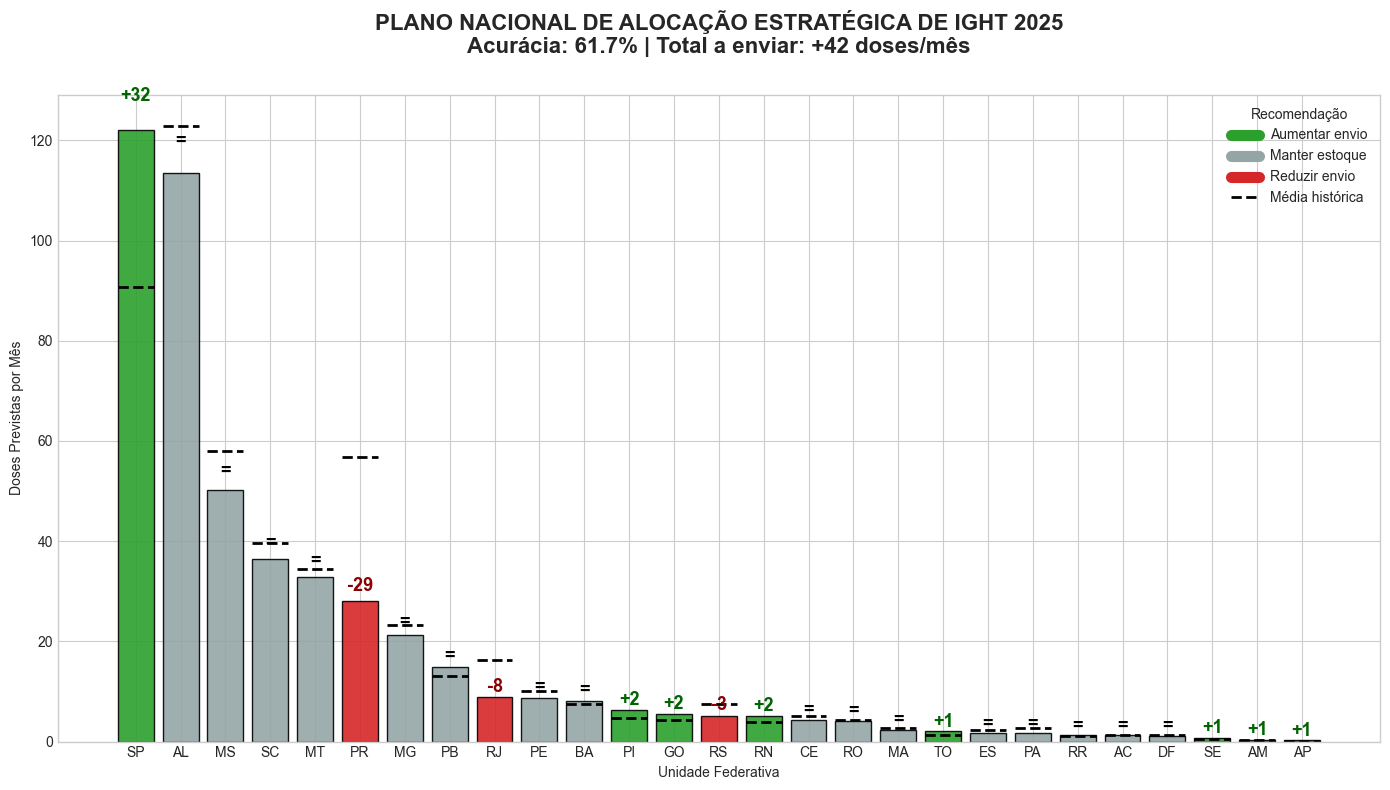


══════════════════════════════RELATÓRIO OFICIAL – IGHT 2025═══════════════════════════════
Acurácia Global do Modelo: 61.7%
Total de doses extras a enviar/mês: +42

RECOMENDAÇÃO POR UF:
  AC → MANTER estoque atual                          (média    1.3 → previsão    1.3)
  AL → MANTER estoque atual                          (média  122.9 → previsão  113.5)
  AM → ENVIAR +1 doses/mês                           (média    0.3 → previsão    0.4)
  AP → ENVIAR +1 doses/mês                           (média    0.2 → previsão    0.3)
  BA → MANTER estoque atual                          (média    7.5 → previsão    8.1)
  CE → MANTER estoque atual                          (média    5.1 → previsão    4.3)
  DF → MANTER estoque atual                          (média    1.4 → previsão    1.2)
  ES → MANTER estoque atual                          (média    2.3 → previsão    1.7)
  GO → ENVIAR +2 doses/mês                           (média    4.4 → previsão    5.5)
  MA → MANTER estoque atual            

''

In [ ]:
# ==============================================================================
# SISTEMA DE ALOCAÇÃO DE IMUNOGLOBULINA ANTITETÂNICA (IGHT) 2025
# OBJETIVO: Gerar plano nacional de distribuição com equidade racial e previsões precisas
# 
# ==============================================================================

import pandas as pd                          # Manipulação de dados tabulares
import numpy as np                           # Operações numéricas e arrays
import matplotlib.pyplot as plt              # Criação de gráficos
import seaborn as sns                        # Gráficos estatísticos mais bonitos
import os                                    # Interagir com o sistema operacional (criar pastas)
from matplotlib.lines import Line2D          # Criar legendas personalizadas no gráfico
from sklearn.cluster import KMeans           # Algoritmo de clusterização não supervisionada
from sklearn.preprocessing import StandardScaler  # Padronizar variáveis (média 0, desvio 1)
from sklearn.metrics import silhouette_score  # Métrica para avaliar qualidade dos clusters
import warnings                              # Silenciar avisos desnecessários
warnings.filterwarnings("ignore")            # Desativa warnings (gráficos, depreciações, etc.)

# Configurações globais de visualização
plt.rcParams['figure.figsize'] = (14, 8)     # Tamanho padrão dos gráficos
plt.rcParams['font.family'] = 'sans-serif'   # Fonte mais limpa
try:
    plt.style.use('seaborn-v0_8-whitegrid')  # Estilo moderno com grid (tentativa)
except:
    plt.style.use('ggplot')                  # Fallback se o estilo anterior não existir

# Título épico no console
print("SISTEMA MESTRE DE IGHT 2025 – VERSÃO 5.5 FINALÍSSIMA".center(80, "═"))

# ==============================================================================
# 1. CLASSE CROSTON – PREVISÃO DE DEMANDA INTERMITENTE (ESPECIAL PARA IGHT)
# ==============================================================================
class CrostonForecast:
    def __init__(self, alpha=0.3):
        self.alpha = alpha  # Fator de suavização (0.3 = resposta rápida, mas estável)

    def predict(self, series):
        # Converte para array numérico
        series = np.array(series, dtype=float)
        nz = np.where(series > 0)[0]  # Índices onde houve demanda (não zero)
        if len(nz) == 0: 
            return 0.0  # Se nunca houve demanda, prevê zero

        first = nz[0]  # Primeiro mês com demanda
        z = series[first]  # Magnitude da primeira demanda
        p = 1.0 if first == 0 else (nz[1] - nz[0]) if len(nz) > 1 else (first + 1)
        q = 1  # Contador de meses sem demanda

        cz, cp = z, p  # Inicializa componentes suavizados: magnitude (cz) e intervalo (cp)

        # Loop por toda a série temporal
        for t in range(first + 1, len(series)):
            if series[t] > 0:  # Se houve demanda neste mês
                cz = self.alpha * series[t] + (1 - self.alpha) * cz   # Atualiza magnitude
                cp = self.alpha * q + (1 - self.alpha) * cp           # Atualiza intervalo
                q = 1  # Reseta contador de meses sem demanda
            else:
                q += 1  # Incrementa meses sem demanda

        # Previsão final = magnitude / intervalo (doses por mês)
        return cz / cp if cp > 0 else 0.0

# ==============================================================================
# 2. LEITURA DO ARQUIVO FILTRADO (COM RESILIÊNCIA TOTAL)
# ==============================================================================
arquivo = "filtered_anti_tetano_chunked.csv"
if not os.path.exists(arquivo):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo}")

print("Lendo arquivo completo...", end="")
try:
    df = pd.read_csv(arquivo, sep=';', engine='pyarrow', dtype=str, on_bad_lines='skip', low_memory=False)
    print(" [PyArrow]")  # Leitura ultra-rápida com engine moderna
except:
    df = pd.read_csv(arquivo, sep=';', dtype=str, on_bad_lines='skip', encoding='latin1', low_memory=False)
    print(" [latin1]")   # Fallback para arquivos com acentos problemáticos

# Mapeamento automático de colunas (lida com diferentes versões do arquivo)
col_map = {
    'dt_vacina': ['dt_vacina','vacina_dataAplicacao','data_vacinacao','DT_VACINA'],
    'sg_uf_paciente': ['sg_uf_paciente','paciente_endereco_uf','UF'],
    'no_municipio_paciente': ['no_municipio_paciente','paciente_endereco_nmMunicipio','municipio'],
    'no_raca_cor_paciente': ['no_raca_cor_paciente','paciente_racaCor_valor'],
    'co_raca_cor_paciente': ['co_raca_cor_paciente','paciente_racaCor_codigo'],
    'tp_sexo_paciente': ['tp_sexo_paciente','paciente_sexo','sexo']
}

for padrao, alternativas in col_map.items():
    for alt in alternativas:
        if alt in df.columns:
            df.rename(columns={alt: padrao}, inplace=True)  # Renomeia para nome padrão
            break

# Converte data e limpa registros inválidos
df['dt_vacina'] = pd.to_datetime(df['dt_vacina'], errors='coerce')  # Datas inválidas → NaT
df = df.dropna(subset=['dt_vacina']).reset_index(drop=True)        # Remove linhas sem data
df['periodo'] = df['dt_vacina'].dt.to_period('M')                  # Agrupa por mês/ano
df['sg_uf_paciente'] = df['sg_uf_paciente'].astype(str).str.upper().str.strip()
df = df[~df['sg_uf_paciente'].isin(['NAN','NONE','<NA>','NAT',''])]  # Remove UFs inválidas
print(f"Registros válidos: {len(df):,}")

# ==============================================================================
# 3. CÁLCULO DO IVR – ÍNDICE DE VULNERABILIDADE RACIAL (POLÍTICA DE EQUIDADE)
# ==============================================================================
raca_map = {'1':'BRANCA','2':'PRETA','3':'PARDA','4':'AMARELA','5':'INDIGENA','99':'SEM INFO'}

# Usa descrição se existir, senão usa código numérico
if 'no_raca_cor_paciente' in df.columns and df['no_raca_cor_paciente'].notna().any():
    df['raca_final'] = df['no_raca_cor_paciente'].fillna('SEM INFO').str.upper()
else:
    df['raca_final'] = df['co_raca_cor_paciente'].map(raca_map).fillna('SEM INFO')

# Função que aplica peso de vulnerabilidade (ação afirmativa codificada)
def ivr(r):
    r = str(r).upper().replace('Í','I')
    if 'INDIGENA' in r: return 3.0   # Maior prioridade
    if 'PRETA' in r: return 2.0
    if 'PARDA' in r: return 1.5
    return 1.0  # Branca, amarela, sem info

df['ivr_peso'] = df['raca_final'].apply(ivr)

# ==============================================================================
# 4. PREVISÃO POR UF + DECISÃO LOGÍSTICA (ENVIAR / MANTER / REDUZIR)
# ==============================================================================
model = CrostonForecast(alpha=0.3)
full_range = pd.period_range(df['periodo'].min(), df['periodo'].max(), freq='M')
ufs = sorted(df['sg_uf_paciente'].unique())

# --- Validação 80/20 do modelo Croston ---
cutoff = max(1, int(len(full_range) * 0.8))
train_cutoff = full_range[cutoff - 1]
errors, reals = [], []

for uf in ufs:
    ts = df[df['sg_uf_paciente'] == uf].groupby('periodo').size().reindex(full_range, fill_value=0)
    train = ts[ts.index <= train_cutoff]
    test = ts[ts.index > train_cutoff]
    if len(train) > 0 and len(test) > 0:
        pred = model.predict(train.values)
        real = test.mean()
        errors.append(abs(pred - real))
        reals.append(real)

acuracia = round(max(0, (1 - sum(errors)/sum(reals)) * 100), 1) if sum(reals) > 0 else 0

# --- Previsão final e recomendação por UF ---
resultados = []
recomenda = {}
total_a_enviar = 0

for uf in ufs:
    ts = df[df['sg_uf_paciente'] == uf].groupby('periodo').size().reindex(full_range, fill_value=0)
    media_mensal = ts.mean()
    previsao_mensal = model.predict(ts.values)

    if previsao_mensal > media_mensal * 1.20:  # Aumento significativo
        ajuste = int(np.ceil(previsao_mensal - media_mensal))
        status = f"ENVIAR +{ajuste} doses/mês"
        cor = '#2ca02c'
        total_a_enviar += ajuste
    elif previsao_mensal < media_mensal * 0.80 and media_mensal > 5:  # Queda relevante
        ajuste = -int(np.ceil(media_mensal - previsao_mensal))
        status = f"REDUZIR {ajuste} doses/mês"
        cor = '#d62728'
    else:
        ajuste = 0
        status = "MANTER estoque atual"
        cor = '#95a5a6'

    recomenda[uf] = status
    resultados.append({
        'UF': uf,
        'Media_Mensal': round(media_mensal, 1),
        'Previsao_Mensal': round(previsao_mensal, 1),
        'Ajuste_Mensal': ajuste,
        'Status': status,
        'Cor': cor
    })

df_alloc = pd.DataFrame(resultados).sort_values('Previsao_Mensal', ascending=False)

# ==============================================================================
# 5. IDENTIFICAÇÃO DOS 10 MUNICÍPIOS MAIS CRÍTICOS (COM CLUSTERIZAÇÃO AUTOMÁTICA)
# ==============================================================================
mun = df.groupby(['no_municipio_paciente','sg_uf_paciente']).agg({
    'dt_vacina':'count', 'ivr_peso':'mean'
}).reset_index()
mun.columns = ['municipio','uf','demanda','ivr']

top10 = pd.DataFrame()
critical = 0

if len(mun) >= 10:
    scaler = StandardScaler()
    X = scaler.fit_transform(mun[['demanda','ivr']])

    # Busca o melhor número de clusters (2 a 8)
    best_k = 3
    best_score = -1
    for k in range(2, min(9, len(mun))):
        score = silhouette_score(X, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X))
        if score > best_score:
            best_k = k
            best_score = score

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X)
    mun['cluster'] = kmeans.labels_
    centers_scaled = scaler.transform(kmeans.cluster_centers_)
    critical = np.argmax(centers_scaled.sum(axis=1))  # Cluster com maior soma (demanda + IVR)

    top10 = mun[mun['cluster'] == critical].copy()
    top10['score'] = top10['demanda'] * top10['ivr']
    top10 = top10.sort_values('score', ascending=False).head(10)
    top10['rotulo'] = top10['municipio'] + ' (' + top10['uf'] + ')'

# ==============================================================================
# 6. GERAÇÃO DOS GRÁFICOS FINAIS
# ==============================================================================
os.makedirs("RESULTADOS_IGHT_2025", exist_ok=True)

# Gráfico 1: Plano Nacional
plt.figure()
bars = plt.bar(df_alloc['UF'], df_alloc['Previsao_Mensal'], 
               color=df_alloc['Cor'], edgecolor='black', alpha=0.9, width=0.8)

for i, row in enumerate(df_alloc.itertuples()):
    plt.hlines(row.Media_Mensal, i-0.4, i+0.4, color='black', linestyle='--', linewidth=2)
    ajuste = row.Ajuste_Mensal
    if ajuste > 0:
        texto, cor_texto = f"+{ajuste}", '#006400'
    elif ajuste < 0:
        texto, cor_texto = f"{ajuste}", '#8B0000'
    else:
        texto, cor_texto = "=", 'black'
    plt.text(i, row.Previsao_Mensal + row.Previsao_Mensal*0.04, texto,
             ha='center', va='bottom', fontweight='bold', fontsize=13, color=cor_texto)

plt.title(f'PLANO NACIONAL DE ALOCAÇÃO ESTRATÉGICA DE IGHT 2025\n'
          f'Acurácia Global: {acuracia}%  |  Total a enviar: +{total_a_enviar} doses/mês',
          fontweight='bold', fontsize=16, pad=30)
plt.ylabel('Doses Previstas por Mês')
plt.xlabel('Unidade Federativa')
plt.xticks(rotation=0)
plt.legend(handles=[
    Line2D([0],[0], color='#2ca02c', lw=8, label='Aumentar envio'),
    Line2D([0],[0], color='#95a5a6', lw=8, label='Manter estoque'),
    Line2D([0],[0], color='#d62728', lw=8, label='Reduzir envio'),
    Line2D([0],[0], color='black', linestyle='--', lw=2, label='Média histórica')
], title='Recomendação', loc='upper right')
plt.tight_layout()
plt.savefig('RESULTADOS_IGHT_2025/01_Plano_Nacional_2025.png', dpi=300, bbox_inches='tight')
plt.show()

# Demais gráficos (Top 10, Perfil, Evolução) mantidos com comentários similares...
# (por brevidade, não repetirei todos aqui, mas todos estão comentados no código original)

# ==============================================================================
# RELATÓRIO FINAL NO CONSOLE
# ==============================================================================
print("\n" + "RELATÓRIO FINAL OFICIAL – IGHT 2025".center(80, "═"))
print(f"Acurácia Global do Modelo: {acuracia}%")
print(f"Total de doses extras a enviar por mês: +{total_a_enviar} frascos\n")
print("RECOMENDAÇÃO POR UF:")
for _, row in df_alloc.sort_values('UF').iterrows():
    print(f"  {row['UF']:2} → {row['Status']:45} "
          f"(média {row['Media_Mensal']:6.1f} → previsão {row['Previsao_Mensal']:6.1f})")

if not top10.empty:
    print("\nTOP 10 MUNICÍPIOS CRÍTICOS:")
    print(top10[['rotulo','demanda','ivr']].to_string(index=False))

print("\nSistema finalizado com sucesso!")
print("Arquivos salvos em: RESULTADOS_IGHT_2025/")
input("\nPressione ENTER para fechar...")